In [1]:

import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from rdkit import Chem

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


Device: cpu


In [2]:

DATA_PATH = "data_curated.csv"

SMILES_COLUMN = None
TARGET_COLUMN = None

BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

HIDDEN_DIM = 64
DROPOUT = 0.20

TEST_SIZE = 0.15
VALID_SIZE = 0.15

MODEL_PATH = "gcn_solubility.pt"


In [3]:

def load_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path.resolve()}")

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    elif path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    else:
        raise ValueError("Supported files: CSV, XLSX, XLS")

df = load_table(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Shape: (9982, 26)


,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Occurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934



Columns:
['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'Solubility', 'SD', 'Occurrences', 'Group', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ', 'BertzCT']


In [4]:

def find_column(columns, candidates):
    lower_map = {str(c).strip().lower(): c for c in columns}

    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    for c in columns:
        c_low = str(c).strip().lower()
        for candidate in candidates:
            if candidate.lower() in c_low:
                return c

    return None

if SMILES_COLUMN is None:
    SMILES_COLUMN = find_column(
        df.columns,
        ["smiles", "canonical smiles", "isomeric smiles", "canonical_smiles"]
    )

if TARGET_COLUMN is None:
    TARGET_COLUMN = find_column(
        df.columns,
        ["logs", "log s", "log solubility", "solubility", "logs (mol/l)", "logS"]
    )

print("SMILES column:", SMILES_COLUMN)
print("Target column:", TARGET_COLUMN)

if SMILES_COLUMN is None or TARGET_COLUMN is None:
    raise ValueError(
        "Could not automatically detect SMILES/target columns. "
        "Set SMILES_COLUMN and TARGET_COLUMN manually in Section 1."
    )


SMILES column: SMILES
Target column: Solubility


In [5]:

work_df = df[[SMILES_COLUMN, TARGET_COLUMN]].copy()
work_df.columns = ["SMILES", "target"]

work_df["SMILES"] = work_df["SMILES"].astype(str).str.strip()
work_df["target"] = pd.to_numeric(work_df["target"], errors="coerce")

work_df = work_df.dropna(subset=["SMILES", "target"]).copy()

def is_valid_smiles(smiles):
    return Chem.MolFromSmiles(smiles) is not None

valid_mask = work_df["SMILES"].apply(is_valid_smiles)
print("Invalid SMILES removed:", int((~valid_mask).sum()))

work_df = work_df[valid_mask].copy()
work_df = work_df.drop_duplicates(subset=["SMILES"]).reset_index(drop=True)

print("Final dataset shape:", work_df.shape)
display(work_df.head())


[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not removing hydrogen atom without neighbors
[12:19:20] WARNING: not r

Invalid SMILES removed: 2
Final dataset shape: (9980, 2)


,SMILES,target
0,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127
1,O=C1Nc2cccc3cccc1c23,-3.254767
2,Clc1ccc(C=O)cc1,-2.177078
3,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409
4,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065


In [6]:

indices = np.arange(len(work_df))

train_valid_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED
)

valid_fraction_of_remaining = VALID_SIZE / (1.0 - TEST_SIZE)

train_idx, valid_idx = train_test_split(
    train_valid_idx,
    test_size=valid_fraction_of_remaining,
    random_state=SEED
)

train_df = work_df.iloc[train_idx].reset_index(drop=True)
valid_df = work_df.iloc[valid_idx].reset_index(drop=True)
test_df  = work_df.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_df)}")
print(f"Valid: {len(valid_df)}")
print(f"Test : {len(test_df)}")


Train: 6986
Valid: 1497
Test : 1497


In [7]:

COMMON_ATOMIC_NUMBERS = [1, 5, 6, 7, 8, 9, 15, 16, 17, 35, 53]

def one_hot_with_unknown(value, allowed):
    return [int(value == x) for x in allowed] + [int(value not in allowed)]

def atom_features(atom):
    features = []
    
    features.extend(one_hot_with_unknown(
        atom.GetAtomicNum(),
        COMMON_ATOMIC_NUMBERS
    ))

    features.append(atom.GetDegree())
    features.append(atom.GetTotalNumHs())
    features.append(atom.GetFormalCharge())
    features.append(int(atom.GetIsAromatic()))
    features.append(int(atom.IsInRing()))

    features.append(atom.GetMass() / 100.0)

    return np.asarray(features, dtype=np.float32)

ATOM_DIM = len(atom_features(Chem.MolFromSmiles("C").GetAtomWithIdx(0)))
print("Atom feature dimension:", ATOM_DIM)


Atom feature dimension: 18


In [8]:

def smiles_to_graph(smiles, target=None):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    x = np.stack(
        [atom_features(atom) for atom in mol.GetAtoms()],
        axis=0
    )

    edges = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        edges.append([i, j])
        edges.append([j, i])

    if edges:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)

    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=edge_index
    )

    if target is not None:
        data.y = torch.tensor([float(target)], dtype=torch.float32)

    data.smiles = smiles

    return data


In [9]:

def build_graph_dataset(frame):
    graphs = []

    for _, row in frame.iterrows():
        try:
            graph = smiles_to_graph(row["SMILES"], row["target"])
            graphs.append(graph)
        except Exception:
            pass

    return graphs

train_graphs = build_graph_dataset(train_df)
valid_graphs = build_graph_dataset(valid_df)
test_graphs = build_graph_dataset(test_df)

print("Train graphs:", len(train_graphs))
print("Valid graphs:", len(valid_graphs))
print("Test graphs :", len(test_graphs))

example = train_graphs[0]
print("\nExample graph:")
print(example)
print("x shape:", example.x.shape)
print("edge_index shape:", example.edge_index.shape)
print("y:", example.y)


[12:19:21] WARNING: not removing hydrogen atom without neighbors
[12:19:21] WARNING: not removing hydrogen atom without neighbors
[12:19:22] WARNING: not removing hydrogen atom without neighbors
[12:19:22] WARNING: not removing hydrogen atom without neighbors
[12:19:22] WARNING: not removing hydrogen atom without neighbors
[12:19:22] WARNING: not removing hydrogen atom without neighbors
[12:19:23] WARNING: not removing hydrogen atom without neighbors
[12:19:23] WARNING: not removing hydrogen atom without neighbors
[12:19:23] WARNING: not removing hydrogen atom without neighbors
[12:19:23] WARNING: not removing hydrogen atom without neighbors
[12:19:23] WARNING: not removing hydrogen atom without neighbors
[12:19:23] WARNING: not removing hydrogen atom without neighbors
[12:19:24] WARNING: not removing hydrogen atom without neighbors
[12:19:24] WARNING: not removing hydrogen atom without neighbors
[12:19:24] WARNING: not removing hydrogen atom without neighbors
[12:19:24] WARNING: not r

Train graphs: 6986
Valid graphs: 1497
Test graphs : 1497

Example graph:
Data(x=[30, 18], edge_index=[2, 60], y=[1], smiles='CO[S]([O-])(=O)=O.CC(C)N(C(C)C)c1sc(N=Nc2ccc(cc2)N(C)C)[n+](C)n1')
x shape: torch.Size([30, 18])
edge_index shape: torch.Size([2, 60])
y: tensor([-1.2597])


[12:19:29] WARNING: not removing hydrogen atom without neighbors
[12:19:29] WARNING: not removing hydrogen atom without neighbors


In [10]:

train_loader = DataLoader(
    train_graphs,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [11]:

class PureGCN(nn.Module):
    def __init__(
        self,
        atom_dim,
        hidden_dim=64,
        dropout=0.2
    ):
        super().__init__()

        self.gcn1 = GCNConv(atom_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)

        graph_dim = 2 * hidden_dim

        self.head = nn.Sequential(
            nn.Linear(graph_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        # Message passing
        x = self.gcn1(x, edge_index)
        x = F.relu(x)

        x = self.gcn2(x, edge_index)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        max_pool = global_max_pool(x, batch)

        graph_embedding = torch.cat(
            [mean_pool, max_pool],
            dim=1
        )

        out = self.head(graph_embedding)

        return out.view(-1)

model = PureGCN(
    atom_dim=ATOM_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
).to(DEVICE)

print(model)


PureGCN(
  (gcn1): GCNConv(18, 64)
  (gcn2): GCNConv(64, 64)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [12]:

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


Total parameters: 13697
Trainable parameters: 13697


In [13]:

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


In [14]:

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    for batch in loader:
        batch = batch.to(DEVICE)

        pred = model(batch)

        y_true.extend(batch.y.view(-1).cpu().numpy())
        y_pred.extend(pred.view(-1).cpu().numpy())

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "y_true": y_true,
        "y_pred": y_pred
    }


In [15]:

history = {
    "train_loss": [],
    "valid_mse": []
}

best_valid_mse = float("inf")
best_epoch = -1

for epoch in range(1, EPOCHS + 1):

    model.train()
    running_loss = 0.0
    n_samples = 0

    for batch in train_loader:
        batch = batch.to(DEVICE)

        optimizer.zero_grad()

        pred = model(batch)
        target = batch.y.view(-1)

        loss = criterion(pred, target)

        loss.backward()
        optimizer.step()

        batch_size = target.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    train_loss = running_loss / n_samples

    valid_metrics = evaluate(model, valid_loader)
    valid_mse = valid_metrics["MSE"]

    history["train_loss"].append(train_loss)
    history["valid_mse"].append(valid_mse)

    if valid_mse < best_valid_mse:
        best_valid_mse = valid_mse
        best_epoch = epoch

        torch.save({
            "model_state_dict": model.state_dict(),
            "atom_dim": ATOM_DIM,
            "hidden_dim": HIDDEN_DIM,
            "dropout": DROPOUT,
            "best_epoch": best_epoch,
            "best_valid_mse": best_valid_mse
        }, MODEL_PATH)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Train MSE: {train_loss:.4f} | "
            f"Valid MSE: {valid_mse:.4f}"
        )

print("\nBest epoch:", best_epoch)
print("Best validation MSE:", best_valid_mse)


Epoch   1 | Train MSE: 5.4841 | Valid MSE: 4.0127
Epoch  10 | Train MSE: 1.9878 | Valid MSE: 1.6917
Epoch  20 | Train MSE: 1.6416 | Valid MSE: 1.4285
Epoch  30 | Train MSE: 1.4337 | Valid MSE: 1.3975
Epoch  40 | Train MSE: 1.2944 | Valid MSE: 1.3174
Epoch  50 | Train MSE: 1.2385 | Valid MSE: 1.3136
Epoch  60 | Train MSE: 1.2003 | Valid MSE: 1.3067
Epoch  70 | Train MSE: 1.1316 | Valid MSE: 1.2089
Epoch  80 | Train MSE: 1.1001 | Valid MSE: 1.3081
Epoch  90 | Train MSE: 1.0392 | Valid MSE: 1.2637
Epoch 100 | Train MSE: 1.0244 | Valid MSE: 1.2036
Epoch 110 | Train MSE: 0.9931 | Valid MSE: 1.1945
Epoch 120 | Train MSE: 0.9801 | Valid MSE: 1.2329
Epoch 130 | Train MSE: 0.9368 | Valid MSE: 1.2443
Epoch 140 | Train MSE: 0.9458 | Valid MSE: 1.1996
Epoch 150 | Train MSE: 0.9033 | Valid MSE: 1.2103
Epoch 160 | Train MSE: 0.8958 | Valid MSE: 1.1934
Epoch 170 | Train MSE: 0.9035 | Valid MSE: 1.1470
Epoch 180 | Train MSE: 0.8488 | Valid MSE: 1.1912
Epoch 190 | Train MSE: 0.8447 | Valid MSE: 1.1203


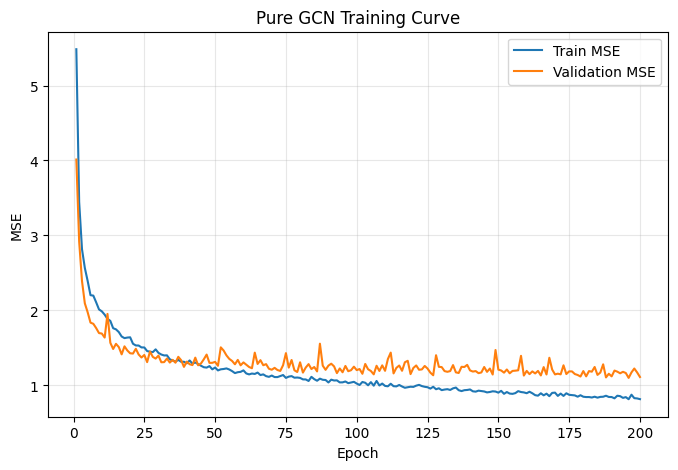

In [16]:

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    history["train_loss"],
    label="Train MSE"
)

plt.plot(
    range(1, EPOCHS + 1),
    history["valid_mse"],
    label="Validation MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Pure GCN Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [17]:

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model = PureGCN(
    atom_dim=checkpoint["atom_dim"],
    hidden_dim=checkpoint["hidden_dim"],
    dropout=checkpoint["dropout"]
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded best epoch:", checkpoint["best_epoch"])
print("Best validation MSE:", checkpoint["best_valid_mse"])


Loaded best epoch: 196
Best validation MSE: 1.1000409126281738


In [18]:

test_metrics = evaluate(model, test_loader)

print(f"Test MSE : {test_metrics['MSE']:.4f}")
print(f"Test RMSE: {test_metrics['RMSE']:.4f}")
print(f"Test MAE : {test_metrics['MAE']:.4f}")
print(f"Test R²  : {test_metrics['R2']:.4f}")


Test MSE : 1.1781
Test RMSE: 1.0854
Test MAE : 0.7641
Test R²  : 0.7841


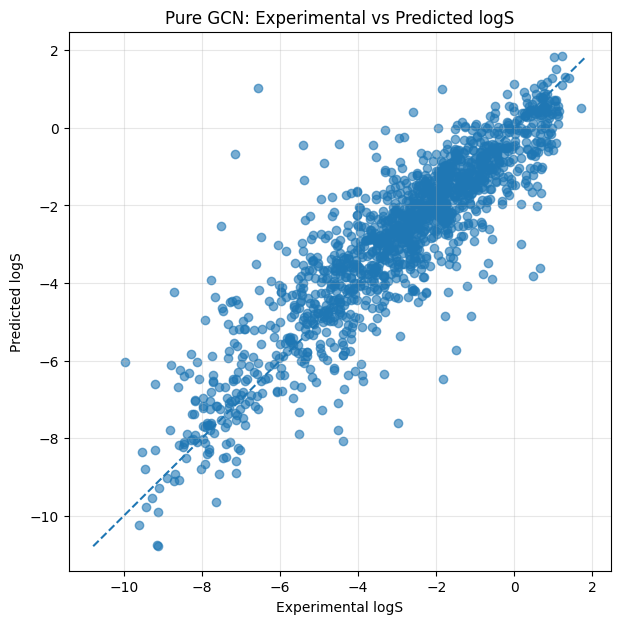

In [19]:

y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]

plt.figure(figsize=(7, 7))

plt.scatter(y_true, y_pred, alpha=0.6)

min_value = min(y_true.min(), y_pred.min())
max_value = max(y_true.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Experimental logS")
plt.ylabel("Predicted logS")
plt.title("Pure GCN: Experimental vs Predicted logS")
plt.grid(alpha=0.3)
plt.show()


In [20]:

@torch.no_grad()
def predict_smiles(smiles, model):
    model.eval()

    graph = smiles_to_graph(smiles)

    graph = graph.to(DEVICE)

    graph.batch = torch.zeros(
        graph.x.size(0),
        dtype=torch.long,
        device=DEVICE
    )

    prediction = model(graph)

    return float(prediction.item())


In [21]:

new_smiles = "CCO"  # ethanol

predicted_logS = predict_smiles(
    new_smiles,
    model
)

print("SMILES:", new_smiles)
print(f"Predicted logS: {predicted_logS:.4f}")


SMILES: CCO
Predicted logS: 0.9404
